# 01 — Data Discovery

**What this notebook establishes:** four properties of the MSCapital dataset that are
not documented anywhere, that a reasonable person would get wrong by assumption, and
that each would silently corrupt a model.

Each section follows the same shape: *what I expected → what I measured → what I changed.*

| # | Finding | Consequence if missed |
|---|---|---|
| 1 | The market table's window is **600 s**, not 60 s | 90% of the book history is discarded |
| 2 | `price = 0` is an **empty-level sentinel**, not a price | mean `rel_spread` reads −0.0064 instead of +0.0013 |
| 3 | a **999-row ceiling** exists but almost never binds | a plausible feature that is constant-zero |
| 4 | `side` / `order_action` encodings are **recoverable from the data** | order-flow features get built backwards |

All numbers below are computed live against BigQuery.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

from src.data.bq_loader import client
from src.config import load_config

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True,
                     "grid.alpha": .3, "font.size": 10})
pd.set_option("display.width", 120)

bq = client()
cfg = load_config()
P, ST = cfg.bigquery.project, cfg.bigquery.datasets.staging

def q(sql: str) -> pd.DataFrame:
    return bq.query(sql).result().to_dataframe()

print("connected to", P)

connected to workintech-working


---
## Finding 1 — the market window is 600 seconds, not 60

**Expectation.** The three event tables describe the same lookback window, so one set of
nested windows `{1, 5, 10, 30, 60}s` should serve all of them.

**Measurement.** `seconds_before_predict` is the distance back from the prediction
instant. If the window really is 60 s, no sample should exceed it.

In [2]:
windows = q(f'''
WITH per_sample AS (
  SELECT 'market' AS tbl, sample_id, MAX(seconds_before_predict) AS mx, COUNT(*) AS n
  FROM `{P}.{ST}.market_train` WHERE month = 0 GROUP BY sample_id
  UNION ALL
  SELECT 'order', sample_id, MAX(seconds_before_predict), COUNT(*)
  FROM `{P}.{ST}.order_train` WHERE month = 0 GROUP BY sample_id
  UNION ALL
  SELECT 'transaction', sample_id, MAX(seconds_before_predict), COUNT(*)
  FROM `{P}.{ST}.transaction_train` WHERE month = 0 GROUP BY sample_id
)
SELECT tbl,
  ROUND(APPROX_QUANTILES(mx,100)[OFFSET(50)],2) AS median_window_s,
  ROUND(MAX(mx),3)  AS max_window_s,
  COUNTIF(mx > 60.001) AS samples_beyond_60s,
  COUNT(*) AS samples,
  ROUND(AVG(n),1) AS avg_rows, MAX(n) AS max_rows
FROM per_sample GROUP BY tbl ORDER BY tbl
''')
windows

,tbl,median_window_s,max_window_s,samples_beyond_60s,samples,avg_rows,max_rows
0,market,595.73,599.599,17653,17653,183.1,205
1,order,59.40,59.999,0,17653,157.5,998
2,transaction,58.42,59.999,0,17653,97.2,970


`market` reaches **599.9 s** and essentially every sample exceeds 60 s; `order` and
`transaction` stop dead at 59.999 s. The tables do **not** share a window.

A second consequence hides in `avg_rows`: market carries ~176 snapshots over 600 s, i.e.
**one snapshot every ~3.4 seconds**. A 1-second market window would therefore be empty
in roughly 71% of samples — so it is not just wrong to reuse the 60 s grid, it is wrong
to reuse the short end of it either.

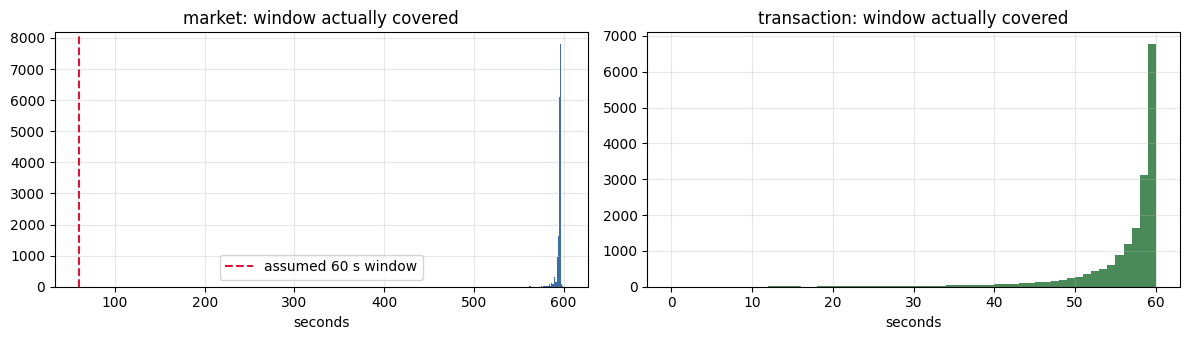

market  : median 595.7s, max 599.6s
transaction: median 58.4s, max 60.0s


In [3]:
mkt = q(f'''
SELECT sample_id, MAX(seconds_before_predict) AS mx
FROM `{P}.{ST}.market_train` WHERE month = 0 GROUP BY sample_id LIMIT 20000
''')
txn = q(f'''
SELECT sample_id, MAX(seconds_before_predict) AS mx
FROM `{P}.{ST}.transaction_train` WHERE month = 0 GROUP BY sample_id LIMIT 20000
''')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].hist(mkt.mx, bins=60, color="#3b6ea5")
ax[0].axvline(60, color="crimson", ls="--", label="assumed 60 s window")
ax[0].set_title("market: window actually covered"); ax[0].set_xlabel("seconds"); ax[0].legend()
ax[1].hist(txn.mx, bins=60, color="#4a8a58")
ax[1].set_title("transaction: window actually covered"); ax[1].set_xlabel("seconds")
plt.tight_layout(); plt.show()

print(f"market  : median {mkt.mx.median():.1f}s, max {mkt.mx.max():.1f}s")
print(f"transaction: median {txn.mx.median():.1f}s, max {txn.mx.max():.1f}s")

**Change made.** Window grids became per-table (`configs/config.yaml`):

```yaml
market:      [5, 10, 30, 60, 120, 300, 600]   # 1 s dropped - would be empty
order:       [1, 5, 10, 30, 60]
transaction: [1, 5, 10, 30, 60]
```

---
## Finding 2 — `price = 0` is a sentinel, not a price

**Expectation.** Prices are normalised around mid ≈ 1.0, so a computed relative spread
should be a small positive number.

**Measurement.** It was not. The mean came out **negative**, which is impossible for a
real order book.

In [4]:
sentinel = q(f'''
SELECT
  COUNT(*) AS rows_total,
  COUNTIF(bid_price_1 = 0) AS bid1_zero,
  COUNTIF(ask_price_1 = 0) AS ask1_zero,
  COUNTIF(bid_price_1 = 0 AND bid_volume_1 = 0) AS bid1_zero_and_zero_volume,
  COUNTIF(ask_price_1 = 0 AND ask_volume_1 = 0) AS ask1_zero_and_zero_volume,
  COUNTIF(bid_price_1 > 0 AND ask_price_1 > 0 AND bid_price_1 >= ask_price_1) AS truly_crossed,
  ROUND(MIN(IF(bid_price_1 > 0, bid_price_1, NULL)), 5) AS min_positive_bid,
  ROUND(MIN(IF(ask_price_1 > 0, ask_price_1, NULL)), 5) AS min_positive_ask
FROM `{P}.{ST}.market_train`
''')
sentinel.T

,0
rows_total,221756611
bid1_zero,133781
ask1_zero,898820
bid1_zero_and_zero_volume,133781
ask1_zero_and_zero_volume,898820
truly_crossed,0
min_positive_bid,0.90919
min_positive_ask,0.91027


Three facts settle it:

1. `price = 0` **always** coincides with `volume = 0` (133,781 and 898,820 rows match exactly).
2. Real prices never go below **0.909**. Zero is nowhere near the price distribution.
3. `truly_crossed = 0` — there is **not one genuinely crossed book** in 221.8M rows.

So zero means *"this level is empty"*. Every apparently crossed book was an artefact of
reading the sentinel as a price.

In [5]:
spread_cmp = q(f'''
SELECT
  ROUND(AVG(SAFE_DIVIDE(ask_price_1 - bid_price_1, (ask_price_1 + bid_price_1)/2)), 6)
    AS naive_mean_rel_spread,
  ROUND(AVG(IF(bid_price_1 > 0 AND ask_price_1 > 0,
      SAFE_DIVIDE(ask_price_1 - bid_price_1, (ask_price_1 + bid_price_1)/2), NULL)), 6)
    AS cleaned_mean_rel_spread
FROM `{P}.{ST}.market_train`
''')
spread_cmp.T

,0
naive_mean_rel_spread,-0.005648
cleaned_mean_rel_spread,0.001258


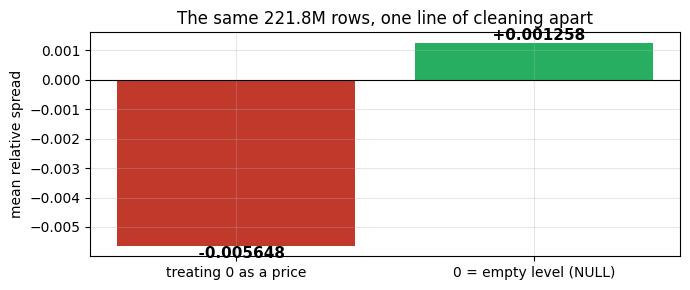

sign flip: -0.005648 -> +0.001258
0.4% of rows were enough to invert the mean, because an empty ask makes
spread = 0 - bid ~= -1.0, which is ~800x a real spread.


In [6]:
vals = [float(spread_cmp.naive_mean_rel_spread[0]), float(spread_cmp.cleaned_mean_rel_spread[0])]
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(["treating 0 as a price", "0 = empty level (NULL)"], vals,
              color=["#c0392b", "#27ae60"])
ax.axhline(0, color="black", lw=.8)
ax.set_ylabel("mean relative spread")
ax.set_title("The same 221.8M rows, one line of cleaning apart")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v, f"  {v:+.6f}", ha="center",
            va="bottom" if v > 0 else "top", fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

print(f"sign flip: {vals[0]:+.6f} -> {vals[1]:+.6f}")
print("0.4% of rows were enough to invert the mean, because an empty ask makes")
print("spread = 0 - bid ~= -1.0, which is ~800x a real spread.")

**Change made.** `src/features/market_features.py` cleans the sentinel *before* deriving
anything (`NULLIF(bid_price_1, 0)` …), and depth imbalance is additionally gated on a
two-sided book — on a one-sided snapshot it degenerates to ±1, a valid but meaningless
number that must not be mixed into the same distribution. The empty-side rate is kept as
its own feature instead.

---
## Finding 3 — a ceiling that turned out not to matter

This one is here because the first answer was **wrong**, and the correction is the point.

**First look.** `MAX(rows per sample)` is exactly 999 for both `order` and `transaction`,
in both splits. Market has no such limit. An exact, shared round number across two
independent tables is not a coincidence, so I concluded the feed was truncated at 999 and
added `is_truncated` features.

**Second look.** A truncation cap should produce a **pile-up** — many samples stuck at the
limit. So how many actually sit there?

In [7]:
cap = q(f"""
WITH o AS (SELECT sample_id, COUNT(*) AS n FROM `{P}.{ST}.order_train` GROUP BY sample_id),
     t AS (SELECT sample_id, COUNT(*) AS n FROM `{P}.{ST}.transaction_train` GROUP BY sample_id)
SELECT 'order' AS tbl, MAX(n) AS max_rows, COUNTIF(n = 999) AS at_999,
       COUNTIF(n >= 995) AS ge_995, COUNTIF(n BETWEEN 900 AND 949) AS band_900_949,
       COUNT(*) AS samples FROM o
UNION ALL
SELECT 'transaction', MAX(n), COUNTIF(n = 999), COUNTIF(n >= 995),
       COUNTIF(n BETWEEN 900 AND 949), COUNT(*) FROM t
""")
cap

,tbl,max_rows,at_999,ge_995,band_900_949,samples
0,transaction,999,6,21,243,1257637
1,order,999,31,135,1641,1257637


**31 out of 1,257,637** for order. **6** for transaction. And the distribution is not
piling up against the limit at all — the 900–949 band holds **1,641** order samples versus
**135** at ≥995. It decays smoothly and simply happens to stop at 999.

The ceiling is real, but it binds for **0.003%** of samples.

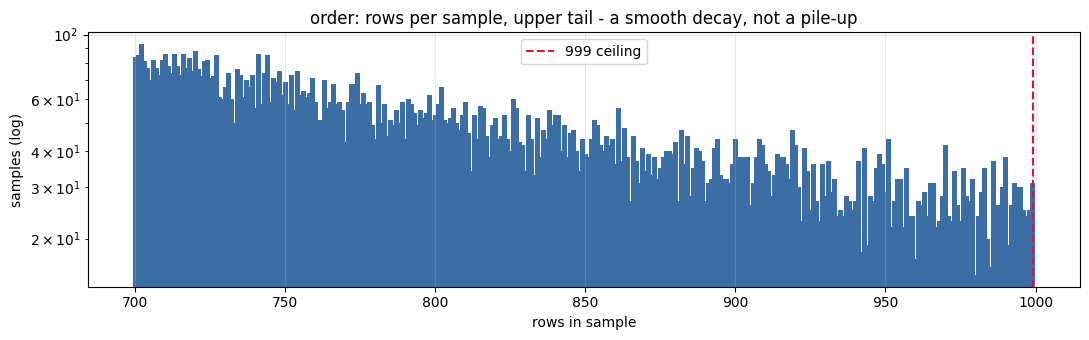

If 999 were a truncation cap, the last bar would tower over its neighbours.
It does not.


In [8]:
rows = q(f"""
SELECT n, COUNT(*) AS samples FROM (
  SELECT sample_id, COUNT(*) AS n FROM `{P}.{ST}.order_train` GROUP BY sample_id)
WHERE n >= 700 GROUP BY n ORDER BY n
""")
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(rows.n, rows.samples, width=1.6, color='#3b6ea5')
ax.axvline(999, color='crimson', ls='--', label='999 ceiling')
ax.set_yscale('log')
ax.set_title('order: rows per sample, upper tail - a smooth decay, not a pile-up')
ax.set_xlabel('rows in sample'); ax.set_ylabel('samples (log)'); ax.legend()
plt.tight_layout(); plt.show()

print('If 999 were a truncation cap, the last bar would tower over its neighbours.')
print('It does not.')

**Change made — and then un-made.** The `is_truncated` features were removed: constant-zero
for 99.997% of rows is a feature no tree can split on. What was kept is
`*_window_covered`, how far back a sample's events actually reach — that one varies
continuously (order: mean 58.3 s, std 3.1 s, min 0.1 s) and carries real information.

`tests/test_feature_sql.py` now asserts the dead flag does **not** come back, with the
measurement recorded as the reason.

The lesson worth keeping: *an exact round number is evidence of a mechanism, not evidence
that the mechanism matters.* Quantifying how often it binds cost one query and removed two
dead features.

---
## Finding 4 — recovering the `side` and `order_action` encodings

Neither is documented. Both are recoverable because prices are normalised around mid ≈ 1.0,
which turns the encoding question into a measurement.

In [9]:
enc = q(f'''
SELECT order_action, side, COUNT(*) AS n,
       ROUND(AVG(price), 6) AS avg_price, ROUND(AVG(volume), 1) AS avg_volume
FROM `{P}.{ST}.order_train`
GROUP BY order_action, side ORDER BY order_action, side
''')
enc

,order_action,side,n,avg_price,avg_volume
0,0,0,65629757,0.997884,1833.2
1,0,1,62471913,1.003563,1939.5
2,1,0,21463755,0.994262,2367.4
3,1,1,20491158,1.006494,2269.0


`side = 0` sits **below** mid, `side = 1` **above**: side 0 is the **BID**, side 1 the **ASK**.

For `order_action` the counts do the work. Over the full training set:
`action=0` → 128.1M, `action=1` → 42.0M, and there are 104.0M transactions. Orders leave
the book by being cancelled or executed, so

    NEW ≈ CANCEL + EXECUTED   →   128.1M ≈ 42.0M + 104.0M  ✓

The reverse reading would require 42.0M new orders to produce 146.0M departures, which is
impossible. So `action=0` is **NEW** and `action=1` is **CANCEL**.

In [10]:
# transaction.side is a different question: it marks the AGGRESSOR.
# Compare each trade against the prevailing mid at that moment.
aggressor = q(f'''
WITH ev AS (
  SELECT sample_id, seconds_before_predict AS s,
         (NULLIF(ask_price_1,0) + NULLIF(bid_price_1,0)) / 2 AS mid,
         CAST(NULL AS FLOAT64) AS trade_price, CAST(NULL AS INT64) AS side
  FROM `{P}.{ST}.market_train` WHERE month = 0
  UNION ALL
  SELECT sample_id, seconds_before_predict, CAST(NULL AS FLOAT64), price, CAST(side AS INT64)
  FROM `{P}.{ST}.transaction_train` WHERE month = 0
),
filled AS (
  SELECT *, LAST_VALUE(mid IGNORE NULLS) OVER (
      PARTITION BY sample_id ORDER BY s DESC
      ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS mid_at_trade
  FROM ev
)
SELECT side, COUNT(*) AS trades,
  ROUND(COUNTIF(trade_price > mid_at_trade)/COUNT(*), 4) AS frac_above_mid,
  ROUND(COUNTIF(trade_price < mid_at_trade)/COUNT(*), 4) AS frac_below_mid,
  ROUND(AVG(trade_price - mid_at_trade) * 1e4, 3) AS avg_bps_vs_mid
FROM filled
WHERE trade_price IS NOT NULL AND mid_at_trade IS NOT NULL
GROUP BY side ORDER BY side
''')
aggressor

,side,trades,frac_above_mid,frac_below_mid,avg_bps_vs_mid
0,0,832378,0.875,0.1187,5.263
1,1,881841,0.107,0.8871,-5.271


`side = 0` trades print **87.5% above** the prevailing mid at **+5.26 bps**; `side = 1`
prints **88.7% below** at **−5.27 bps**. The symmetry is near perfect.

So `transaction.side = 0` is a **buyer-initiated** trade (the aggressor lifts the ask) and
`side = 1` is **seller-initiated**. This agrees with the order-table convention, which
confirms that signed-volume features were being computed in the right direction.

---
## Finding 5 — a bug this analysis caught in my own code

The fourth finding above is about the data. This one is about the pipeline, and it was
found the same way: by **recomputing features independently** rather than re-reading the
code that produced them.

The `*_last` features are meant to describe the order book at the moment closest to the
prediction instant. The original implementation took each field with its own
`ARRAY_AGG(field IGNORE NULLS ORDER BY seconds ASC LIMIT 1)`.

That is subtly wrong. On a one-sided snapshot `mid` is NULL but `depth_imb_1` is a valid
(degenerate) ±1, so the two fields would skip to **different snapshots**. An independent
recomputation over 17,556 samples measured the disagreement:

| field | deviation before | after |
|---|---:|---:|
| `mkt_mid_last` | 0.0 | 0.0 |
| `mkt_depth_imb1_last` | **1.9942** | **0.0** |

1.994 is the entire width of the `[-1, 1]` range: the two methods were picking essentially
opposite values.

**Change made.** One `last_snap` STRUCT is taken from the last *valid* (two-sided)
snapshot and every `*_last` field is read from it, so they are guaranteed to describe the
same instant. `tests/test_feature_sql.py` now fails if a per-field `ARRAY_AGG` ever
reappears.

---
## Summary

| Finding | How it was found | What changed |
|---|---|---|
| market window is 600 s | measured `MAX(seconds)` per table instead of assuming | per-table window grids |
| `price = 0` is a sentinel | a mean spread came out negative, which is impossible | clean sentinel before deriving; gate depth imbalance |
| 999 ceiling is inert | asked how often it actually binds: 0.003% | dropped the dead flag, kept covered-span |
| `side` / `order_action` | prices are mid-normalised, so encoding is measurable | order-flow features built in the right direction |
| cross-snapshot `*_last` bug | independent recomputation, not code review | single `last_snap` STRUCT + a regression test |

The common thread: every one of these was found by **measuring something that could have
been assumed**. None would have raised an error — the pipeline would have run cleanly and
produced a quietly worse model.